In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [4]:
load_dotenv()

True

In [5]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [6]:
subgraph_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [7]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [8]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

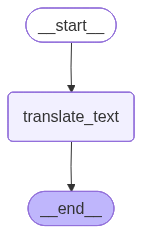

In [9]:
subgraph

In [10]:
parent_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [11]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [12]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [13]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [14]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

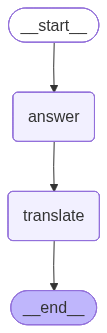

In [15]:
graph = parent_builder.compile()

graph

In [17]:
graph.invoke({'question': 'What is separate state in langgraph? answer in 3 lines'})

{'question': 'What is separate state in langgraph? answer in 3 lines',
 'answer_eng': "Separate state in LangGraph occurs when parallel branches execute.\nEach branch operates on its own isolated copy of the graph's current state.\nThis prevents conflicts, allowing independent computation before results are merged back.",
 'answer_hin': 'लैंगग्राफ में पृथक स्थिति तब उत्पन्न होती है जब समानांतर शाखाएँ निष्पादित होती हैं।\nप्रत्येक शाखा ग्राफ़ की वर्तमान स्थिति की अपनी पृथक प्रति पर कार्य करती है।\nयह टकरावों को रोकता है, जिससे परिणामों को वापस मिलाए जाने से पहले स्वतंत्र गणना संभव हो पाती है।'}